In [ ]:
### Imports ###
!pip install py7zr
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from zipfile import ZipFile
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler,FunctionTransformer,OrdinalEncoder
from sklearn.pipeline import Pipeline
import os,time,py7zr,datetime,random

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.3/495.3 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 10.9 MB/s eta 0:00:00


In [ ]:
### Set Seed ###
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [51]:
### Extract Data ###

import os
import shutil
import pandas as pd
from zipfile import ZipFile

MAX_ROWS = 10000000

# Remove old extraction folder if it exists
if os.path.exists("readableData"):
    shutil.rmtree("readableData")

# Create extraction folder
os.makedirs("readableData", exist_ok=True)

# Download dataset from Kaggle
!kaggle datasets download -d ruiyuanfan/corporacin-favorita-grocery-sales-forecasting

# Extract ZIP contents
print("Extracting dataset...")

with ZipFile(
    "corporacin-favorita-grocery-sales-forecasting.zip",
    "r"
) as zip_ref:
    zip_ref.extractall("readableData")

print("Extraction complete.")

# Verify files
print("\nFiles found:")
print(os.listdir("readableData"))

# Load training data
print("\nLoading train.csv...")

ds = pd.read_csv(
    "readableData/train.csv",
    index_col="id",
    nrows=MAX_ROWS,
    parse_dates=["date"]
)

# Fill missing promotion values
ds["onpromotion"] = ds["onpromotion"].fillna(False)

print("\nDataset Loaded Successfully!")
print("Shape:", ds.shape)

display(ds.head())

Dataset URL: https://www.kaggle.com/datasets/ruiyuanfan/corporacin-favorita-grocery-sales-forecasting
License(s): unknown
corporacin-favorita-grocery-sales-forecasting.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracting dataset...
Extraction complete.

Files found:
['stores.csv', 'holidays_events.csv', 'oil.csv', 'train.csv', 'transactions.csv', 'items.csv', 'test.csv', 'sample_submission.csv']

Loading train.csv...

Dataset Loaded Successfully!
Shape: (10000000, 5)


/tmp/ipykernel_1973/396736715.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ds["onpromotion"] = ds["onpromotion"].fillna(False)


,date,store_nbr,item_nbr,unit_sales,onpromotion
id,,,,,
0,2013-01-01,25,103665,7.0,False
1,2013-01-01,25,105574,1.0,False
2,2013-01-01,25,105575,2.0,False
3,2013-01-01,25,108079,1.0,False
4,2013-01-01,25,108701,1.0,False


In [16]:
print(ds.shape)
print()

print(ds.columns)
print()

print(ds.dtypes)

(1000000, 5)

Index(['date', 'store_nbr', 'item_nbr', 'unit_sales', 'onpromotion'], dtype='object')

date           datetime64[ns]
store_nbr               int64
item_nbr                int64
unit_sales            float64
onpromotion              bool
dtype: object


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [24]:
### Data Preprocessing ###

# Target
y = ds["unit_sales"]

# IMPORTANT:
# Do NOT include unit_sales in X.
# Otherwise the model learns the answer directly.

X = ds[["date","store_nbr", "item_nbr", "onpromotion"]]

X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.4, random_state=SEED)

X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.5,
    random_state=SEED)


dat_cols = ["date"]
num_cols = ["store_nbr", "item_nbr", "onpromotion"] # These are treated as numerical and scaled.
cat_cols = [] # Empty, as these are now treated as numerical for scaling.

##Build preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols), # Scaling store_nbr, item_nbr, onpromotion
        ("datetime",OrdinalEncoder(),dat_cols),
    ],
    remainder="drop" # Drop any other columns not explicitly transformed (none in this case)
)

X_train_p = preprocess.fit_transform(X_train)
X_val_p   = preprocess.transform(X_val)
X_test_p  = preprocess.transform(X_test)
# Verify processed feature shapes
print("Processed shapes:", X_train_p.shape, X_val_p.shape, X_test_p.shape)

Processed shapes: (600000, 4) (200000, 4) (200000, 4)


In [26]:
### Build First Model ###
def build_basic_model(
    input_dim: int,
    depth: int = 5,
    width: int = 100,
    activation: str = "relu",
    kernel_initializer: str | keras.initializers.Initializer = None,
    use_batchnorm: bool = False,
    dropout_rate: float = 0,
    l2_weight: float = 0,
) -> keras.Model:

    reg = keras.regularizers.L2(l2=l2_weight) if l2_weight and l2_weight > 0 else None

    inputs = keras.Input(shape=(input_dim ,))
    x = inputs

    for _ in range(depth):
        x = layers.Dense(
            width,
            activation=None,
            kernel_initializer=kernel_initializer,
            kernel_regularizer=reg ,
        )(x)

        if use_batchnorm:
            x = layers.BatchNormalization()(x)

        x = layers.Activation(activation=activation)(x)

        if dropout_rate and dropout_rate > 0:
            x = layers.Dropout(rate=dropout_rate)(x)

    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

input_dim = X_train_p.shape[1]
deep_model = build_basic_model(input_dim=input_dim, depth=6, width=256)
deep_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,497 (1.26 MB)

 Trainable params: 330,497 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
### Compile & Fit Functions ###

def compile_model(model: keras.Model, optimizer: keras.optimizers.Optimizer):
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.MeanSquaredError(),
        metrics=[keras.metrics.MeanAbsoluteError(name="mae"),
                  keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    return model

def fit_model(model: keras.Model, epochs: int = 20, batch_size: int = 256):
    history = model.fit(
        X_train_p, y_train,
        validation_data=(X_val_p, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=True
    )
    return history

print(X_train_p)
print(y_train)
print(X_val_p)
print(y_val)

[[-1.05289764  0.74467843  0.          9.        ]
 [ 1.01181373  0.74427315  0.         13.        ]
 [ 0.46527248 -1.32696496  0.          6.        ]
 ...
 [-1.05289764  0.61039457  0.          4.        ]
 [ 0.7081797   0.56780028  0.         17.        ]
 [ 1.67980858 -0.99642185  0.          3.        ]]
id
333136     5.0
515905     5.0
230477    16.0
967322    14.0
610942     5.0
          ... 
259178    47.0
365838    27.0
131932    13.0
671155    20.0
121958     1.0
Name: unit_sales, Length: 600000, dtype: float64
[[-0.87071722  0.48745205  0.         14.        ]
 [ 1.07254053  1.12336788  0.         12.        ]
 [-1.47798527  0.85366998  0.          6.        ]
 ...
 [ 1.01181373  1.05949458  0.         10.        ]
 [ 0.6474529  -1.48896625  0.         17.        ]
 [ 1.67980858 -1.52255534  0.         17.        ]]
id
536753     3.0
477010    13.0
208543    18.0
232740    13.0
860070     1.0
          ... 
128962    17.0
113496     5.0
392080     1.0
669591     5.0
683726

Epoch 1/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 403.0198 - mae: 7.4038 - rmse: 20.0754 - val_loss: 352.5141 - val_mae: 7.6208 - val_rmse: 18.7754
Epoch 2/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 398.4944 - mae: 7.6574 - rmse: 19.9623 - val_loss: 352.5146 - val_mae: 7.6227 - val_rmse: 18.7754
Epoch 3/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 398.4942 - mae: 7.6574 - rmse: 19.9623 - val_loss: 352.5148 - val_mae: 7.6231 - val_rmse: 18.7754
Epoch 4/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 397.3521 - mae: 7.5592 - rmse: 19.9337 - val_loss: 346.9748 - val_mae: 7.3381 - val_rmse: 18.6273
Epoch 5/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 393.8971 - mae: 7.4818 - rmse: 19.8468 - val_loss: 350.0394 - val_mae: 7.8074 - val_rmse: 18.7093
Epoch 6/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 393.2499 - mae: 7.4784 - rmse: 19.8305 - val_loss: 348.9964 - val_mae: 7.6865 - val_rmse: 18.6814
Epoch 7/20
2344/2344 ━━━━━━━━━━━━━━

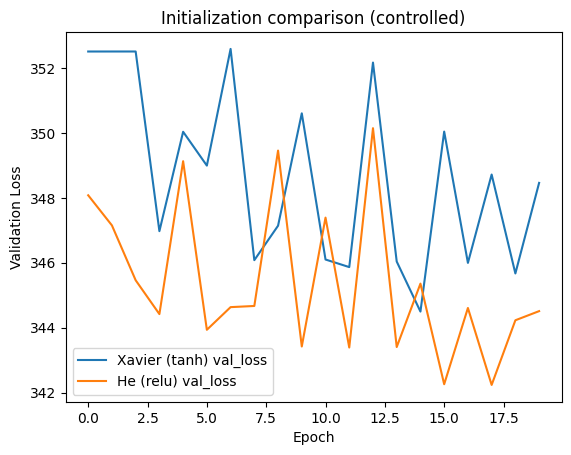

In [29]:
### Compile & Fit Different Model Types ###
xavier = keras.initializers.GlorotNormal(seed=SEED)
he     = keras.initializers.HeNormal(seed=SEED)

model_xavier = compile_model(
    build_basic_model(
        input_dim=input_dim,
        depth=10,
        width=10,
        activation="tanh",
        kernel_initializer=xavier
    ),
    keras.optimizers.Adam(learning_rate=1e-3)
)

model_he = compile_model(
    build_basic_model(
        input_dim=input_dim,
        depth=10,
        width=10,
        activation="relu",
        kernel_initializer=he
    ),
    keras.optimizers.Adam(learning_rate=1e-3)
)

# function call- do not change
hist_xavier = fit_model(model_xavier, epochs=20)
hist_he = fit_model(model_he, epochs=20)

plt.figure()
plt.plot(hist_xavier.history["val_loss"], label="Xavier (tanh) val_loss")
plt.plot(hist_he.history["val_loss"], label="He (relu) val_loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Initialization comparison (controlled)")
plt.show()

In [30]:
test_results = model_he.evaluate(
    X_test_p,
    y_test,
    verbose=0
)

print("Test Loss :", test_results[0])
print("Test MAE  :", test_results[1])
print("Test RMSE :", test_results[2])

Test Loss : 392.0069274902344
Test MAE  : 7.367404937744141
Test RMSE : 19.799165725708008


##Starting GRU Model Testing

In [69]:
### Load Holiday Data ###

holidays = pd.read_csv(
    "readableData/holidays_events.csv",
    parse_dates=["date"]
)

print(holidays.head())

### Holiday Indicator ###

holiday_dates = holidays["date"].unique()

daily_sales["is_holiday"] = (
    daily_sales["date"]
    .isin(holiday_dates)
    .astype(int)
)

daily_sales.head()

        date     type    locale locale_name                    description  \
0 2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1 2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2 2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3 2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4 2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  


,date,unit_sales,is_holiday
0,2013-01-01,42.0,1
1,2013-01-02,111.0,0
2,2013-01-03,37.0,0
3,2013-01-04,97.0,0
4,2013-01-05,73.0,1


In [70]:
from sklearn.preprocessing import MinMaxScaler

sales_scaler = MinMaxScaler()

sales_scaled = sales_scaler.fit_transform(
    daily_sales[["unit_sales"]]
)

In [71]:
holiday_feature = daily_sales[
    ["is_holiday"]
].values

combined_features = np.hstack(
    [sales_scaled, holiday_feature]
)

print(combined_features.shape)

(232, 2)


In [55]:
daily_sales = (
    gru_df
    .groupby("date")["unit_sales"]
    .sum()
    .reset_index()
)

print(daily_sales.shape)

daily_sales.head()

(232, 2)


,date,unit_sales
0,2013-01-01,42.0
1,2013-01-02,111.0
2,2013-01-03,37.0
3,2013-01-04,97.0
4,2013-01-05,73.0


(232, 1)


In [74]:
WINDOW = 30

X_gru = []
y_gru = []

for i in range(WINDOW, len(combined_features)):

    X_gru.append(
        combined_features[i-WINDOW:i]
    )

    y_gru.append(
        sales_scaled[i]
    )

X_gru = np.array(X_gru)
y_gru = np.array(y_gru)

print(X_gru.shape)
print(y_gru.shape)

(202, 30, 2)
(202, 1)


In [58]:
print(gru_df.shape)
print(daily_sales.shape)
print(X_gru.shape)
print(y_gru.shape)

(232, 5)
(232, 2)
(202, 30, 1)
(202, 1)


In [75]:
split_idx = int(0.8 * len(X_gru))

X_train_gru = X_gru[:split_idx]
X_test_gru  = X_gru[split_idx:]

y_train_gru = y_gru[:split_idx]
y_test_gru  = y_gru[split_idx:]

print(X_train_gru.shape)
print(X_test_gru.shape)

(161, 30, 2)
(41, 30, 2)


In [76]:
### Final GRU Model ###

gru_model = keras.Sequential([

    keras.Input(shape=(30,2)),

    layers.GRU(
        64,
        return_sequences=True
    ),

    layers.Dropout(0.2),

    layers.GRU(
        32
    ),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(1)

])

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 30, 64)         │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,009 (89.88 KB)

 Trainable params: 23,009 (89.88 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
print(daily_sales.shape)
print(combined_features.shape)
print(X_gru.shape)
print(y_gru.shape)

(232, 3)
(232, 2)
(202, 30, 2)
(202, 1)


In [78]:
split_idx = int(0.8 * len(X_gru))

X_train_gru = X_gru[:split_idx]
X_test_gru = X_gru[split_idx:]

y_train_gru = y_gru[:split_idx]
y_test_gru = y_gru[split_idx:]

print(X_train_gru.shape)
print(X_test_gru.shape)

print(y_train_gru.shape)
print(y_test_gru.shape)

(161, 30, 2)
(41, 30, 2)
(161, 1)
(41, 1)


In [79]:
gru_model = keras.Sequential([

    keras.Input(shape=(30,2)),

    layers.GRU(
        64,
        return_sequences=True
    ),

    layers.Dropout(0.2),

    layers.GRU(
        32
    ),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(1)

])

gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_5 (GRU)                     │ (None, 30, 64)         │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,009 (89.88 KB)

 Trainable params: 23,009 (89.88 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
gru_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

In [82]:
## Added to help overfitting once val_loss remains
## relatively constant and prevent it from getting worse
## see Epochs 16-32 for refernce on stoppage when val_loss
## increases to 0.0040

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [83]:
history_gru = gru_model.fit(
    X_train_gru,
    y_train_gru,
    validation_data=(
        X_test_gru,
        y_test_gru
    ),
    epochs=200,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - loss: 0.0464 - mae: 0.1540 - rmse: 0.2155 - val_loss: 0.0062 - val_mae: 0.0684 - val_rmse: 0.0788
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0294 - mae: 0.1225 - rmse: 0.1715 - val_loss: 0.0049 - val_mae: 0.0585 - val_rmse: 0.0702
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0300 - mae: 0.1243 - rmse: 0.1733 - val_loss: 0.0053 - val_mae: 0.0609 - val_rmse: 0.0726
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0301 - mae: 0.1226 - rmse: 0.1735 - val_loss: 0.0046 - val_mae: 0.0566 - val_rmse: 0.0675
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0290 - mae: 0.1211 - rmse: 0.1704 - val_loss: 0.0046 - val_mae: 0.0566 - val_rmse: 0.0676
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0289 - mae: 0.1210 - rmse: 0.1701 - val_loss: 0.0045 - val_mae: 0.0562 - val_rmse: 0.0674
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0286 - mae: 0.1204 - rmse:

In [84]:
gru_results = gru_model.evaluate(
    X_test_gru,
    y_test_gru,
    verbose=0
)

print("GRU Test Loss :", gru_results[0])
print("GRU Test MAE  :", gru_results[1])
print("GRU Test RMSE :", gru_results[2])

GRU Test Loss : 0.003888986073434353
GRU Test MAE  : 0.0505838505923748
GRU Test RMSE : 0.062361735850572586


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


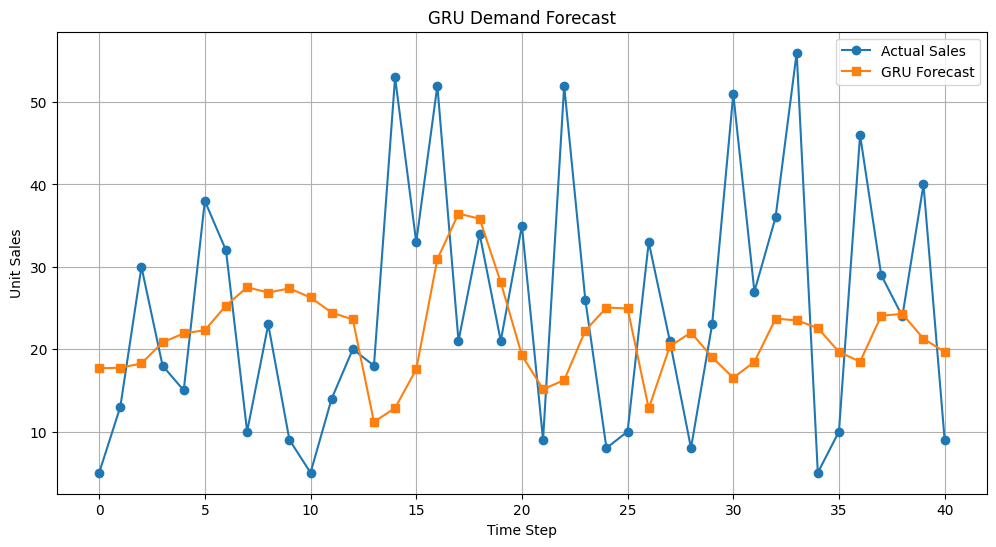

In [86]:
preds = gru_model.predict(X_test_gru)

preds_actual = sales_scaler.inverse_transform(preds)
actual_sales = sales_scaler.inverse_transform(y_test_gru)

plt.figure(figsize=(12,6))

plt.plot(actual_sales,
         marker='o',
         label="Actual Sales")

plt.plot(preds_actual,
         marker='s',
         label="GRU Forecast")

plt.title("GRU Demand Forecast")
plt.xlabel("Time Step")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True)

plt.show()

In [52]:
print("Min date:", ds["date"].min())
print("Max date:", ds["date"].max())
print("Unique dates:", ds["date"].nunique())
print("Rows:", len(ds))

Min date: 2013-01-01 00:00:00
Max date: 2013-08-21 00:00:00
Unique dates: 233
Rows: 10000000
